In [6]:
%config InlineBackend.figure_format = 'retina'

from pathlib import Path
import os
import sys
# import matplotlib.pyplot as plt
# import numpy as np

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src import load_image, population, rendering
from src.ga import GeneticAlgorithm, fitness, mutate, cross_over
from src.ga import StageConfig, run_staged_triangle_optimization


In [7]:
individual = population.create_random_individual()
individual[:5]

[Triangle(x1=177, y1=141, x2=58, y2=385, x3=173, y3=334, r=200, g=181, b=160, a=177),
 Triangle(x1=73, y1=22, x2=141, y2=269, x3=238, y3=373, r=247, g=139, b=174, a=6),
 Triangle(x1=180, y1=392, x2=8, y2=387, x3=164, y3=275, r=59, g=123, b=79, a=100),
 Triangle(x1=234, y1=293, x2=193, y2=171, x3=197, y3=371, r=51, g=35, b=186, a=64),
 Triangle(x1=202, y1=289, x2=103, y2=173, x3=279, y3=209, r=212, g=183, b=197, a=67)]

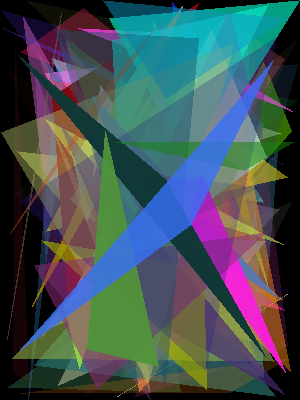

In [8]:
random_image = rendering.render_individual(individual=individual)
random_image

This random initialization confirms that the representation and rendering pipeline are functioning correctly.


In [9]:
# --- Import original paiting image --- #
image_path = os.path.join(project_root, "images/girl_pearl_earing.png")
target_array = load_image.load_target_image(image_path)
print(f"{target_array.shape} -> (H, W, 3) array with RGB values in [0, 255]")

(400, 300, 3) -> (H, W, 3) array with RGB values in [0, 255]


In [ ]:
ga = GeneticAlgorithm(
    target=target_array,
    seeded=True,
    fitness_function=fitness.compute_rmse_plus_structure,
    population_size=250,
    generations=3000,
    crossover_function=cross_over.two_point_crossover,
    crossover_rate=0.85,
    mutation_function=mutate.random_triangle_mutation,
    mutation_rate=0.025,
    adaptive_mutation=True,
    mutation_rate_bounds=(0.003, 0.10),
    stagnation_window=35,
    random_immigrants=1,
    elitism=5,
    selection_type="tournament",
    logs=True,
    evaluation_backend="process",
    n_jobs=8,
    chunksize=5,
    progress=True,
    progress_interval=10,
)

best_fitness, history = ga.run()
best_individual = ga.best_individual

[GA] gen 1/3000 | best=0.262691 | gen_best=0.262691 | mut_rate=0.1000 | mutated_offspring=244 | mutated_triangles=2455
[GA] gen 11/3000 | best=0.217806 | gen_best=0.217806 | mut_rate=0.0997 | mutated_offspring=244 | mutated_triangles=2288
[GA] gen 21/3000 | best=0.204794 | gen_best=0.204794 | mut_rate=0.0994 | mutated_offspring=244 | mutated_triangles=2425
[GA] gen 31/3000 | best=0.194038 | gen_best=0.194038 | mut_rate=0.0990 | mutated_offspring=244 | mutated_triangles=2297
[GA] gen 41/3000 | best=0.186611 | gen_best=0.186611 | mut_rate=0.0987 | mutated_offspring=244 | mutated_triangles=2256
[GA] gen 51/3000 | best=0.180702 | gen_best=0.180702 | mut_rate=0.0984 | mutated_offspring=244 | mutated_triangles=2315
[GA] gen 61/3000 | best=0.174551 | gen_best=0.174551 | mut_rate=0.0981 | mutated_offspring=244 | mutated_triangles=2260
[GA] gen 71/3000 | best=0.169586 | gen_best=0.169586 | mut_rate=0.0977 | mutated_offspring=244 | mutated_triangles=2330
[GA] gen 81/3000 | best=0.165637 | gen_be

In [12]:
best_fitness

0.09965842319652438

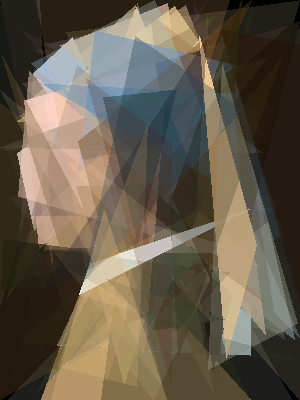

In [13]:
rendering.render_individual(individual=best_individual)

In [14]:
stages = [
    StageConfig(
        n_triangles=40,
        generations=600,
        mutation_rate=0.035,
        crossover_rate=0.85,
        adaptive_mutation=True,
        mutation_rate_bounds=(0.008, 0.10),
        stagnation_window=20,
        random_immigrants=2,
    ),
    StageConfig(
        n_triangles=70,
        generations=900,
        mutation_rate=0.030,
        crossover_rate=0.85,
        adaptive_mutation=True,
        mutation_rate_bounds=(0.005, 0.10),
        stagnation_window=28,
        random_immigrants=1,
    ),
    StageConfig(
        n_triangles=100,
        generations=1500,
        mutation_rate=0.025,
        crossover_rate=0.85,
        adaptive_mutation=True,
        mutation_rate_bounds=(0.003, 0.10),
        stagnation_window=35,
        random_immigrants=1,
    ),
]

result = run_staged_triangle_optimization(
    target=target_array,
    fitness_function=fitness.compute_rmse_plus_structure,
    population_size=250,
    stages=stages,
    elitism=5,
    selection_type="tournament",
    logs=True,
    crossover_function=cross_over.two_point_crossover_two_children,
    mutation_function=mutate.random_triangle_mutation,
    evaluation_backend="process",
    n_jobs=8,
    chunksize=5,
    seeded=True,
    # progress=True,
    # progress_interval=10,
    seed_mutation_rate=0.05,
)

In [15]:
best_individual_staged = result.best_individual
best_fitness_staged = result.best_fitness
best_fitness_staged

0.09517569178715349

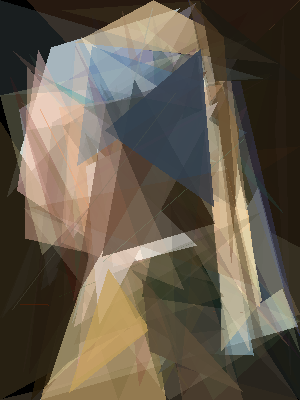

In [16]:
rendering.render_individual(individual=best_individual_staged)